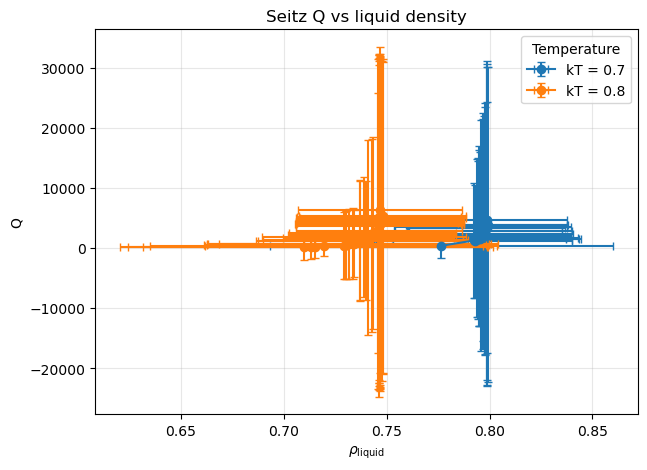

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers import paths

seitz_path = paths.MASTER_CSVS_V3_ROOT / "seitz_master.csv"
seitz = pd.read_csv(seitz_path)

required_columns = [
    "status",
    "Q",
    "Q_uncertainty",
    "rho_liquid",
    "rho_liquid_uncertainty",
    "source_kT",
]
missing = [column for column in required_columns if column not in seitz.columns]
if missing:
    raise RuntimeError(
        "Missing Seitz uncertainty columns: "
        + ", ".join(missing)
        + ". Re-run Seitz_CSV.ipynb to rebuild seitz_master.csv."
    )

plot_data = (
    seitz[
        (seitz["status"] == "seitz_computed")
        & seitz["Q"].notna()
        & seitz["rho_liquid"].notna()
        & seitz["source_kT"].notna()
    ]
    .copy()
    .sort_values(["source_kT", "rho_liquid"])
)

for column in ["rho_liquid_uncertainty", "Q_uncertainty"]:
    plot_data[column] = pd.to_numeric(plot_data[column], errors="coerce")
    plot_data.loc[plot_data[column] < 0, column] = np.nan

fig, ax = plt.subplots(figsize=(7, 5))

for kT, group in plot_data.groupby("source_kT"):
    xerr = group["rho_liquid_uncertainty"].to_numpy()
    yerr = group["Q_uncertainty"].to_numpy()
    ax.errorbar(
        group["rho_liquid"],
        group["Q"],
        xerr=None if np.isnan(xerr).all() else xerr,
        yerr=None if np.isnan(yerr).all() else yerr,
        marker="o",
        linewidth=1.5,
        capsize=3,
        label=f"kT = {kT:g}",
    )

ax.set_xlabel(r"$\rho_\mathrm{liquid}$")
ax.set_ylabel("Q")
ax.set_title("Seitz Q vs liquid density")
ax.legend(title="Temperature")
ax.grid(True, alpha=0.3)

plt.show()
